# Task 2A - 06 Final fit, forecast and submission
Fit the production models on all history (through 2026-03-28), forecast the 10 weeks, validate the file, save models and bands, and demonstrate inference from the saved model.

In [1]:
import sys, warnings; warnings.filterwarnings('ignore')
sys.path.append('../../tools/task2a')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, joblib, json
from task2a_common import *
from task2a_features import *
from task2a_models import *
from task2a_validation import *
pd.set_option('display.width', 220); pd.set_option('display.max_columns', 50); pd.set_option('display.max_rows', 100)
plt.rcParams.update({'figure.dpi': 90, 'axes.grid': True, 'grid.alpha': .25})
for d in (INTERIM, METRICS, FIGURES): d.mkdir(parents=True, exist_ok=True)
o, cal = load_orders(); cal2 = enrich_calendar(cal); panel = build_panel(o, cal2)


In [2]:
fc = Forecaster().fit(panel)
joblib.dump(fc, MODELS / 'task2a_models.joblib')
ti = pd.read_csv(RAW / 'test' / 'task2a_test_inputs.csv')
fops = future_ops(cal2, panel)
out = fc.weekly(fops, ti)
sub = out[['row_id', 'pred_total_volume_m3', 'pred_chilled_volume_m3']]
sub.to_csv(PREDICTIONS / 'submission_task2a.csv', index=False)
print(sub.shape); sub.head()

(60, 3)


,row_id,pred_total_volume_m3,pred_chilled_volume_m3
0,W0000,538.463,196.659
1,W0001,79.760,0.000
2,W0002,23.290,0.000
3,W0003,1024.273,379.483
4,W0004,138.280,0.000


## Submission checks

In [3]:
tmpl = pd.read_csv(RAW / 'templates' / 'submission_task2a.csv')
assert list(sub.row_id) == list(tmpl.row_id) and len(sub) == 60, 'row_id set/order differs from template'
assert sub.notna().all().all() and (sub.drop(columns='row_id') >= 0).all().all()
assert (sub.pred_chilled_volume_m3 <= sub.pred_total_volume_m3).all()
assert (out[out.brand != 'Fresh'].pred_chilled_volume_m3 == 0).all()
used = fops[(fops.iso_year == 2026) & fops.iso_week.between(14, 23)]
assert used.is_operating.eq(1).all() and (used.dow != 6).all()
print('all checks passed | operating days per week used:', used.groupby('iso_week').size().to_dict())

all checks passed | operating days per week used: {14: 6, 15: 6, 16: 4, 17: 6, 18: 5, 19: 6, 20: 6, 21: 6, 22: 6, 23: 6}


## Forecast vs last year (same ISO weeks) and bands

In [4]:
bp = json.load(open(METRICS / 'task2a_band_params.json'))
out['p10'] = np.where(out.brand == 'Tech', (out.pred_total_volume_m3 + bp['Tech_additive'][0]).clip(lower=0), out.pred_total_volume_m3 * out.brand.map({'Fresh': bp['Fresh'][0], 'Style': bp['Style'][0], 'Tech': np.nan}))
out['p90'] = np.where(out.brand == 'Tech', out.pred_total_volume_m3 + bp['Tech_additive'][1], out.pred_total_volume_m3 * out.brand.map({'Fresh': bp['Fresh'][1], 'Style': bp['Style'][1], 'Tech': np.nan}))
out.drop(columns=['row_id']).round(1).to_csv(PREDICTIONS / 'task2a_forecast_with_bands.csv', index=False)
hist = panel[(panel.iso_year == 2025) & panel.iso_week.between(14, 23)].groupby(['depot', 'brand', 'iso_week']).vol.sum().unstack()
f_tab = out.pivot_table(index=['depot', 'brand'], columns='iso_week', values='pred_total_volume_m3')
print('Forecast 2026 (m3)'); print(f_tab.round(0)); print('\nActual 2025, same ISO weeks'); print(hist.round(0)); print('\nforecast / 2025 total:', round(f_tab.sum().sum() / hist.sum().sum(), 3))

Forecast 2026 (m3)
iso_week              14      15     16      17     18     19     20      21      22     23
depot      brand                                                                           
Kandy      Fresh   538.0   745.0  360.0   562.0  516.0  519.0  524.0   532.0   618.0  517.0
           Style    80.0   105.0   51.0    80.0   82.0   75.0   78.0    79.0    79.0   76.0
           Tech     23.0    24.0   20.0    24.0   20.0   23.0   23.0    23.0    25.0   23.0
Peliyagoda Fresh  1024.0  1413.0  673.0  1066.0  996.0  987.0  994.0  1009.0  1176.0  985.0
           Style   138.0   191.0  117.0   139.0   97.0  132.0  136.0   138.0   134.0  132.0
           Tech     33.0    35.0   22.0    34.0   24.0   33.0   33.0    33.0    37.0   33.0

Actual 2025, same ISO weeks
iso_week              14      15     16     17     18      19      20     21     22      23
depot      brand                                                                           
Kandy      Fresh   524.0   697.0

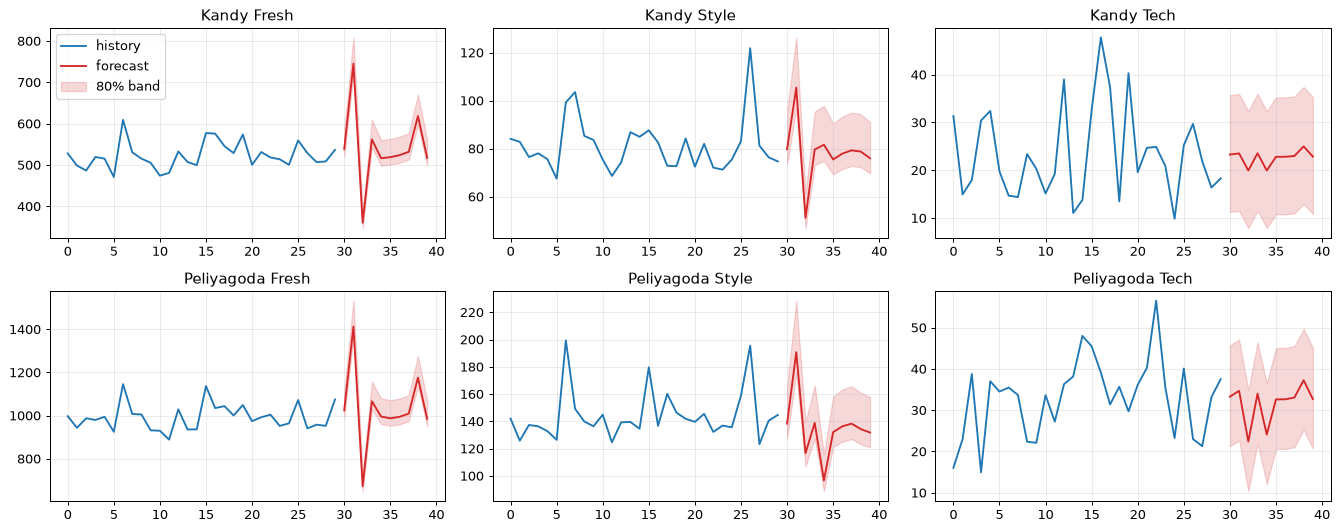

In [5]:
fig, axs = plt.subplots(2, 3, figsize=(15, 6))
for a, (dep, b) in zip(axs.ravel(), SERIES):
    h = panel[(panel.depot == dep) & (panel.brand == b) & (panel.date >= '2025-09-01')].groupby(['iso_year', 'iso_week']).vol.sum().values
    g = out[(out.depot == dep) & (out.brand == b)].sort_values('iso_week')
    x = np.arange(len(h), len(h) + len(g))
    a.plot(range(len(h)), h, label='history'); a.plot(x, g.pred_total_volume_m3, 'C3', label='forecast'); a.fill_between(x, g.p10, g.p90, color='C3', alpha=.18, label='80% band'); a.set_title(f'{dep} {b}')
axs[0, 0].legend(); plt.tight_layout(); plt.savefig(FIGURES / '06_forecast.png'); plt.show()

## Capacity read-out for planners (chilled share of Fresh)

In [6]:
cap = out[out.brand == 'Fresh'].pivot_table(index='iso_week', columns='depot', values='pred_chilled_volume_m3').round(0)
cap['total chilled m3/week'] = cap.sum(axis=1); cap

depot,Kandy,Peliyagoda,total chilled m3/week
iso_week,,,
14,197.0,379.0,576.0
15,273.0,524.0,797.0
16,133.0,247.0,380.0
17,206.0,395.0,601.0
18,191.0,378.0,569.0
19,190.0,366.0,556.0
20,191.0,368.0,559.0
21,195.0,375.0,570.0
22,229.0,440.0,669.0


## Inference demo - loads the saved model and prints inputs and predictions

In [7]:
fc2 = joblib.load(MODELS / 'task2a_models.joblib')
demo = ti.iloc[[0, 1, 2, 3, 4, 5, 6, 12, 18, 54]]          # a mix of depots, brands and weeks incl. New Year (15, 16)
print('INPUT'); print(demo.to_string(index=False))
pred = fc2.weekly(fops, demo)
print('\nPREDICTIONS'); print(pred[['row_id', 'depot', 'brand', 'iso_week', 'pred_total_volume_m3', 'pred_chilled_volume_m3']].to_string(index=False))
chk = sub.set_index('row_id').loc[pred.row_id]
assert np.allclose(chk.pred_total_volume_m3.values, pred.pred_total_volume_m3.values), 'reloaded model differs from the submission'
print('\nreloaded model reproduces the submission rows: OK')

INPUT
row_id      depot brand  iso_year  iso_week
 W0000      Kandy Fresh      2026        14
 W0001      Kandy Style      2026        14
 W0002      Kandy  Tech      2026        14
 W0003 Peliyagoda Fresh      2026        14
 W0004 Peliyagoda Style      2026        14
 W0005 Peliyagoda  Tech      2026        14
 W0006      Kandy Fresh      2026        15
 W0012      Kandy Fresh      2026        16
 W0018      Kandy Fresh      2026        17
 W0054      Kandy Fresh      2026        23



PREDICTIONS
row_id      depot brand  iso_week  pred_total_volume_m3  pred_chilled_volume_m3
 W0000      Kandy Fresh        14               538.463                 196.659
 W0001      Kandy Style        14                79.760                   0.000
 W0002      Kandy  Tech        14                23.290                   0.000
 W0003 Peliyagoda Fresh        14              1024.273                 379.483
 W0004 Peliyagoda Style        14               138.280                   0.000
 W0005 Peliyagoda  Tech        14                33.275                   0.000
 W0006      Kandy Fresh        15               745.243                 273.445
 W0012      Kandy Fresh        16               360.162                 133.096
 W0018      Kandy Fresh        17               561.835                 205.662
 W0054      Kandy Fresh        23               517.152                 189.517

reloaded model reproduces the submission rows: OK
